In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [3]:
data = pd.read_csv("dataset3.csv")

# Feature Engineering

In [ ]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data['publish_hour'] = data['Date'].dt.hour.fillna(12).astype(int)
data['publish_weekday'] = data['Date'].dt.dayofweek.fillna(0).astype(int)
data['publish_month'] = data['Date'].dt.month.fillna(1).astype(int)

data['hashtag_count'] = data['Hashtags'].astype(str).str.count('#')
data['hashtag_length'] = data['Hashtags'].astype(str).str.len()

data['like_view_ratio'] = (data['Likes'] / data['Views'].replace(0, np.nan)).fillna(0)
data['retweet_view_ratio'] = (data['Retweets'] / data['Views'].replace(0, np.nan)).fillna(0)
data['reply_view_ratio'] = (data['Replies'] / data['Views'].replace(0, np.nan)).fillna(0)

In [5]:
data['content_length'] = data['Content'].astype(str).str.len()
data['word_count'] = data['Content'].astype(str).str.split().str.len()
data['mention_count'] = data['Mentions'].astype(str).str.count('@')

data['engagement_score'] = (
    data['Likes'] * 0.4 + 
    data['Retweets'] * 0.3 + 
    data['Replies'] * 0.3
)

In [6]:
threshold = data['Views'].quantile(0.7)
data['high_views'] = (data['Views'] >= threshold).astype(int)

# Feature Selection

In [7]:
features = [
    'Likes', 'Retweets', 'Replies',
    'like_view_ratio', 'retweet_view_ratio', 'reply_view_ratio',
    'engagement_score',
    'hashtag_count', 'hashtag_length',
    'content_length', 'word_count', 'mention_count',
    'publish_hour', 'publish_weekday', 'publish_month'
]

x = data[features].fillna(0)
y = data['high_views']

# Train-Test Split

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# Model Architecture

In [9]:
model = keras.Sequential([

    layers.Input(shape=(x_train_scaled.shape[1],)),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(1, activation='sigmoid')
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

# Model Compilation






# Training Callbacks

In [11]:
history = model.fit(
    x_train_scaled, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4710 - loss: 0.9191 - val_accuracy: 0.7037 - val_loss: 0.6573 - learning_rate: 0.0010
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6561 - loss: 0.6290 - val_accuracy: 0.7963 - val_loss: 0.6153 - learning_rate: 0.0010
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6541 - loss: 0.6350 - val_accuracy: 0.8333 - val_loss: 0.5889 - learning_rate: 0.0010
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7063 - loss: 0.5545 - val_accuracy: 0.8333 - val_loss: 0.5709 - learning_rate: 0.0010
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7199 - loss: 0.5727 - val_accuracy: 0.8333 - val_loss: 0.5466 - learning_rate: 0.0010
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7352 - loss: 0.4797 - val_accuracy: 0.8333 - val_loss: 0.5285 - learning_rate: 0.0010
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7677 - loss: 0.4565 - val_acc

In [12]:
y_pred_prob = model.predict(x_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


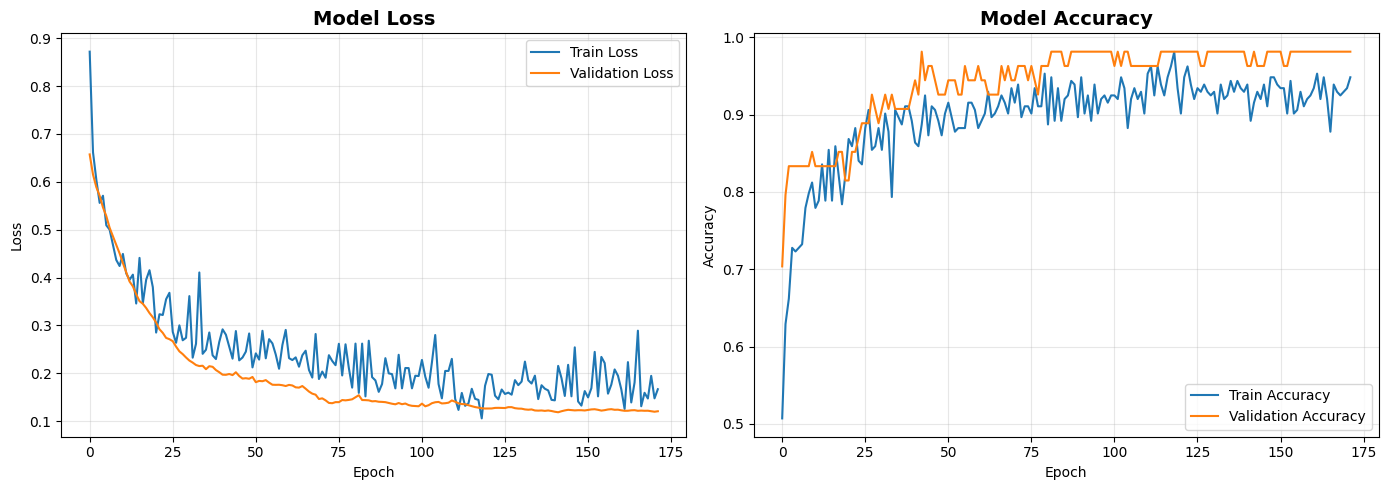

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
train_pred = (model.predict(x_train_scaled) >= 0.5).astype(int)
test_pred = (model.predict(x_test_scaled) >= 0.5).astype(int)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Gap:", train_acc - test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Train Accuracy: 0.9625468164794008
Test Accuracy: 0.9253731343283582
Gap: 0.03717368215104255
